# Analiza comparativă a modelelor de clasificare pentru predicția riscului de boală cardiacă

## 1. Definirea problemei

În acest notebook este analizată o problemă de clasificare binară, având ca scop predicția prezenței bolii cardiace pe baza unor caracteristici clinice și demografice ale pacienților.

Variabila țintă este `target`, iar variabilele de intrare descriu informații precum vârsta, sexul, tipul durerii toracice, tensiunea arterială în repaus, colesterolul și alți indicatori medicali relevanți.

Problema are relevanță practică deoarece astfel de date pot fi folosite pentru identificarea mai rapidă a pacienților cu risc crescut. Un model de machine learning nu înlocuiește decizia medicală, dar poate funcționa ca instrument în evaluarea inițială a riscului.

Am ales acest set de date deoarece este potrivit pentru analiza comparativă între mai mulți algoritmi de clasificare și permite atât evaluarea performanței, cât și interpretarea rezultatelor.

### Relevanța practică a problemei

Această problemă este relevantă deoarece predicția prezenței unei afecțiuni cardiace poate ajuta la identificarea persoanelor cu risc ridicat. Un model de machine learning nu înlocuiește diagnosticul medical, însă poate fi un instrument ajutător în analiza datelor pacienților și în prioritizarea cazurilor care necesită investigații suplimentare.

Am ales această problemă deoarece este o aplicație practică importantă a clasificării binare, iar setul de date conține caracteristici medicale ușor de interpretat, ceea ce permite atât evaluarea performanței modelelor, cât și explicarea predicțiilor prin metode precum SHAP.

### Clasele variabile țintă

Variabila țintă este `target`, care indică prezența sau absența bolii cardiace. Valorile variabilei țintă sunt:

- `0` - absența bolii cardiace
- `1` - prezența bolii cardiace

Prin urmare, problema abordată este una de clasificare binară, obiectivul fiind ca modelul să învețe dintre caracteristicile pacientului și clasa asociată acestuia.

## 2. Obiectivul analizei

Scopul analizei este antrenarea, evaluarea și compararea mai multor modele de clasificare pentru predicția variabilei `target`. Vor fi analizate atât performanțele modelelor de bază, cât și versiunile avansate ale celor mai bune modele, folosind metrici specifice clasificării, curbe de învățare și tehnici de explicabilitate.

## 3. Încărcarea și inspectarea inițială a datelor

In [86]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns",None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [185]:
df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [88]:
print("Shape:",df.shape)

display(df.info())

print("\nValori lipsa:")
display(df.isnull().sum())

print("\nLinii duplicate:", df.duplicated().sum())

Shape: (1025, 14)
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


None


Valori lipsa:


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Linii duplicate: 723


In [89]:
print("Distributia claselor:")
display(df["target"].value_counts().sort_index())

print("\nDistributia procentuala:")
display((df["target"].value_counts(normalize=True).sort_index() * 100).round(2))

display(df.describe().T)

Distributia claselor:


target
0    499
1    526
Name: count, dtype: int64


Distributia procentuala:


target
0   48.680
1   51.320
Name: proportion, dtype: float64

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
sex,1025.000,0.696,0.460,0.000,0.000,1.000,1.000,1.000
cp,1025.000,0.942,1.030,0.000,0.000,1.000,2.000,3.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
fbs,1025.000,0.149,0.357,0.000,0.000,0.000,0.000,1.000
restecg,1025.000,0.530,0.528,0.000,0.000,1.000,1.000,2.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
exang,1025.000,0.337,0.473,0.000,0.000,0.000,1.000,1.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200


### Observații

Datele nu conțin valori lipsă, iar distribuția claselor este una echilibrată. Totuși,exixtența unui număr mare de duplicată indică faptul că este nevoie de o etapă de curățare a setului de date înainte de modelare.

## 4. Curățarea datelor și analiza exploratorie

In [90]:
initial_shape = df.shape

df = df.drop_duplicates().reset_index(drop=True)

print("Forma initiala:", initial_shape)
print("Forma dupa eliminarea duplicatelor:", df.shape)
print("Duplicate ramase:", df.duplicated().sum())

Forma initiala: (1025, 14)
Forma dupa eliminarea duplicatelor: (302, 14)
Duplicate ramase: 0


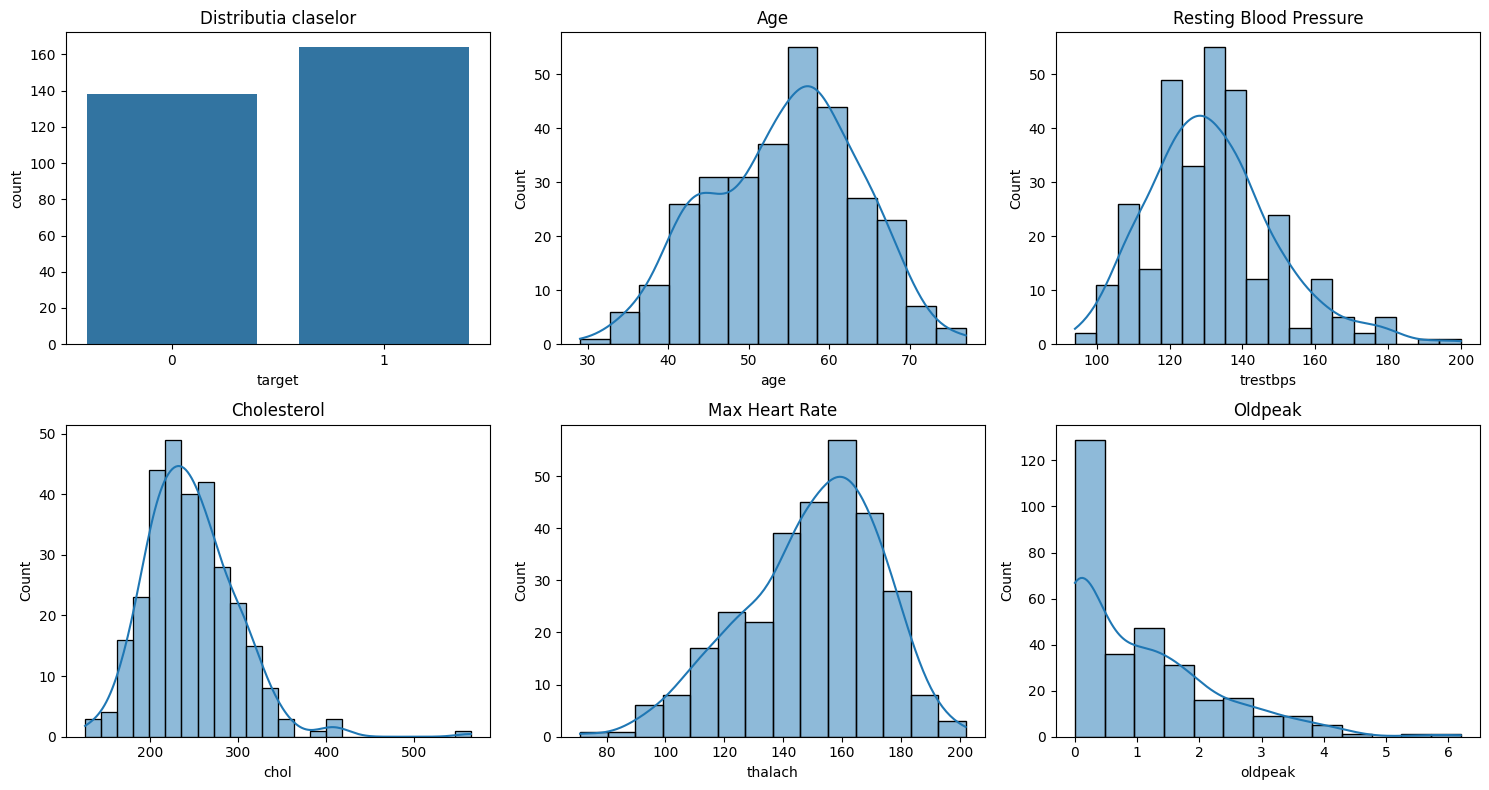

In [91]:
fig, axes=plt.subplots(2, 3, figsize=(15,8))

sns.countplot(data=df, x="target", ax=axes[0, 0])
axes[0, 0].set_title("Distributia claselor")

sns.histplot(df["age"], kde=True, ax=axes[0, 1])
axes[0, 1].set_title("Age")

sns.histplot(df["trestbps"], kde=True, ax=axes[0, 2])
axes[0, 2].set_title("Resting Blood Pressure")

sns.histplot(df["chol"], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Cholesterol")

sns.histplot(df["thalach"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Max Heart Rate")

sns.histplot(df["oldpeak"], kde=True, ax=axes[1, 2])
axes[1, 2].set_title("Oldpeak")

plt.tight_layout()
plt.show()

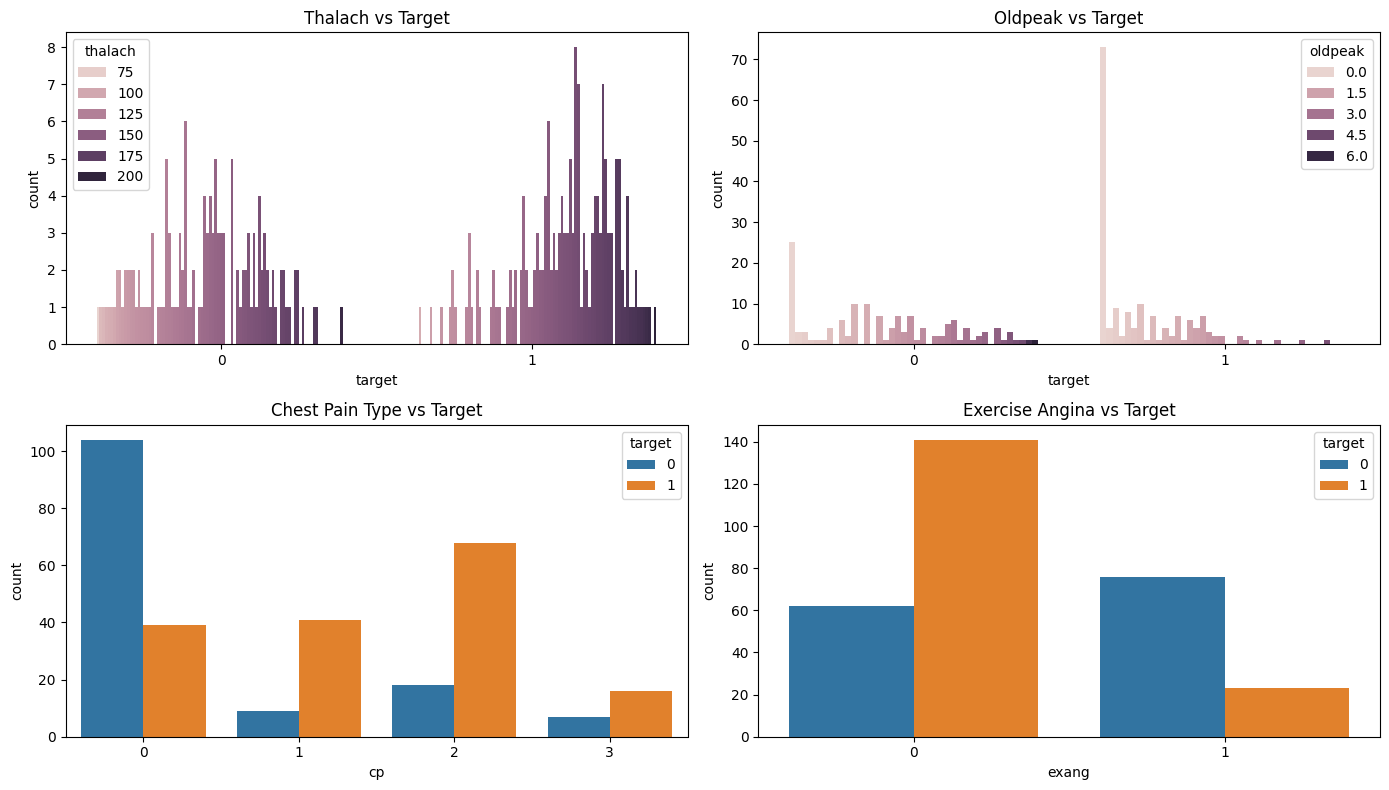

In [92]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.countplot(data=df, x="target", hue="thalach", ax=axes[0, 0])
axes[0, 0].set_title("Thalach vs Target")

sns.countplot(data=df, x="target", hue="oldpeak", ax=axes[0, 1])
axes[0, 1].set_title("Oldpeak vs Target")

sns.countplot(data=df, x="cp", hue="target", ax=axes[1, 0])
axes[1, 0].set_title("Chest Pain Type vs Target")

sns.countplot(data=df, x="exang", hue="target", ax=axes[1, 1])
axes[1, 1].set_title("Exercise Angina vs Target")

plt.tight_layout()
plt.show()

### Observții

După eliminarea duplicatelor, setul de date rămâne echilibrat din punctul de vedere al claselor. Variabile precum `thalach`, `oldpeak`, `cp` și `exang` par a fi relevante pentru variabila țintă.

## 5. Pregătirea datelor pentru modelare

In [93]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("Train set:", X_train.shape)
print("Test set:", X_test.shape)

Train set: (226, 13)
Test set: (76, 13)


In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
print("Train target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print((y_test.value_counts(normalize=True) * 100).round())

Train target distribution:
target
1   54.420
0   45.580
Name: proportion, dtype: float64

Test target distribution:
target
1   54.000
0   46.000
Name: proportion, dtype: float64


### Observații

Datele au fost împărțite în proporție de 75% pentru antrenare și 25% pentru testare, folosind stratificare pentru păstrarea distribuției claselor. Am făcut și o versiune standardizată a caracteristicilor, necesară pentru algoritmiii sensibili la scalarea datelor, precum Logistic Regession, KNN și SVM. Pentru modelele bazate pe arbori au fost păstrate și datele în formă originală, deoarece acestea nu necesită scalare.

## 6. Antrenarea modelelor de bază
### 6.1 Logistic Regression

In [96]:
from sklearn.linear_model import LogisticRegression

results = []

log_reg = LogisticRegression(max_iter=2000, random_state=42)

log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]

In [97]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision": precision_score(y_test, y_pred_lr),
    "Recall": recall_score(y_test, y_pred_lr),
    "F1 Score": f1_score(y_test, y_pred_lr),
    "ROC-AUC": roc_auc_score(y_test, y_prob_lr)
}

results.append(lr_results)
pd.DataFrame([lr_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803,0.783,0.878,0.828,0.875


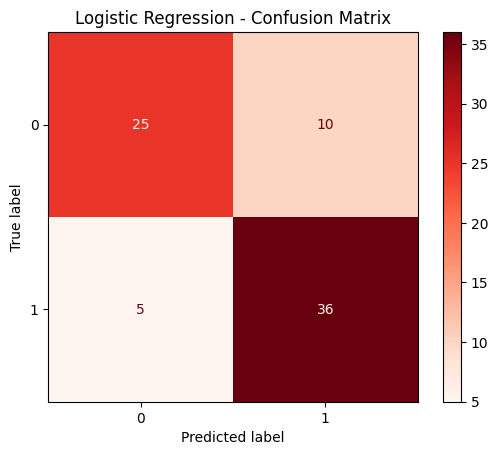

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

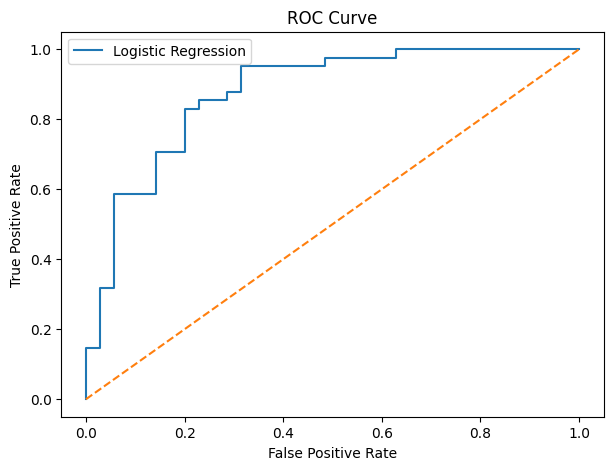

In [99]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Logistic Regression oferă un punct de referință foarte bun pentru viitoarele comparații. Fiind un model liniar, rezultatele sale sunt utile pentru a evalua dacă relația dintre caracteristici și variabila țintă poate fi observată eficient fără metode mai complexe.

### 6.2 Gaussian Naive Bayes

In [100]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train_scaled, y_train)

y_pred_gnb = gnb.predict(X_test_scaled)
y_prob_gnb = gnb.predict_proba(X_test_scaled)[:,1]

In [101]:
gnb_results = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(y_test, y_pred_gnb),
    "Precision": precision_score(y_test, y_pred_gnb),
    "Recall": recall_score(y_test, y_pred_gnb),
    "F1 Score": f1_score(y_test, y_pred_gnb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_gnb)
}

results.append(gnb_results)
pd.DataFrame([gnb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880


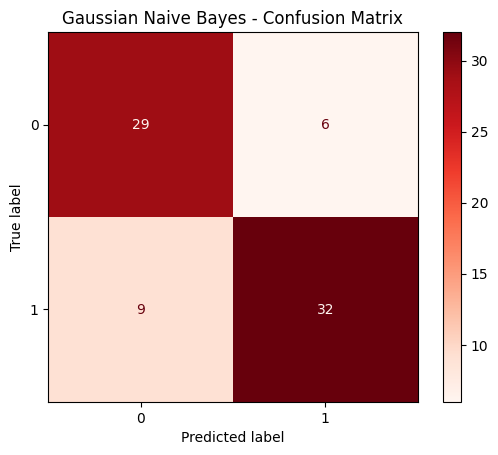

In [102]:
cm = confusion_matrix(y_test, y_pred_gnb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Gaussian Naive Bayes - Confusion Matrix")
plt.show()

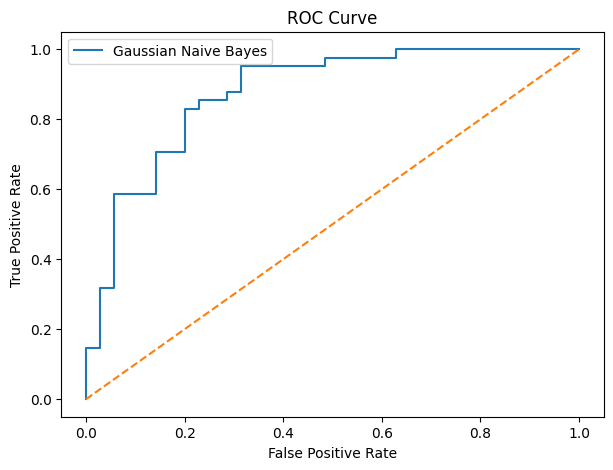

In [103]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label="Gaussian Naive Bayes")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Gaussian Naive Bayes este un model eficient și foarte rapid, util ca punct de comparație pentru algoritmii mai complecși. Peformanța sa depinde de cât de bine sunt respectate principiile de independență între caracteristici.

### 6.3 K-Nearest Neighbors (KNN)

In [104]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]

In [105]:
knn_results = {
    "Model": "K-Nearest Neighbors",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn),
    "ROC-AUC": roc_auc_score(y_test, y_prob_knn)
}

results.append(knn_results)
pd.DataFrame([knn_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,K-Nearest Neighbors,0.789,0.791,0.829,0.809,0.829


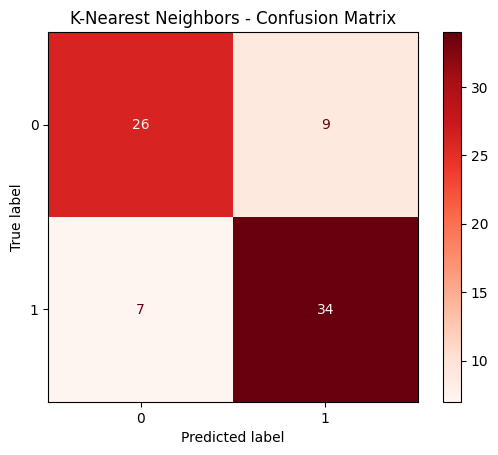

In [106]:
cm = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("K-Nearest Neighbors - Confusion Matrix")
plt.show()

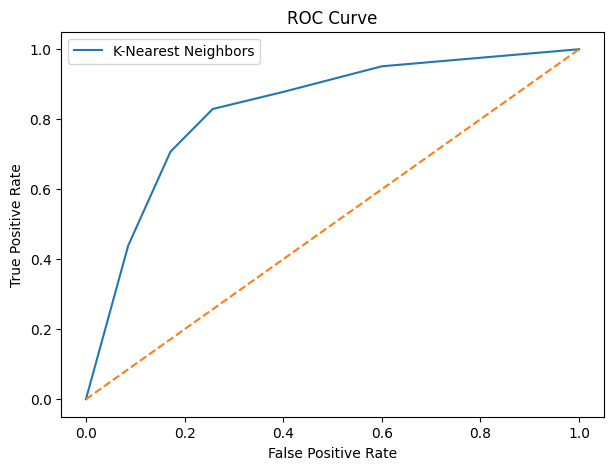

In [107]:
fpr, tpr, _ = roc_curve(y_test, y_prob_knn)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="K-Nearest Neighbors")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
K-Nearest Neighbors clasifică observațiile pe baza celor mai apropriați vecini din setul de antrenare. Modelul este sensibil la scalarea datelor, motiv pentru care a fost antrenat pe varianta standardizată a caracteristicilor.

### 6.4 Support Vector Machine (SVM)

In [108]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

In [109]:
svm_results = {
    "Model": "Support Vector Machine",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm),
    "Recall": recall_score(y_test, y_pred_svm),
    "F1 Score": f1_score(y_test, y_pred_svm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_svm)
}

results.append(svm_results)
pd.DataFrame([svm_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Support Vector Machine,0.789,0.791,0.829,0.809,0.845


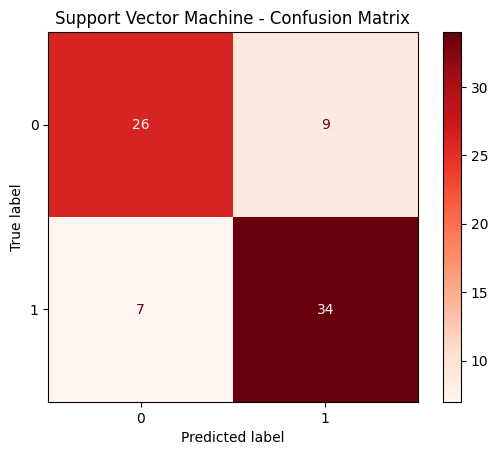

In [110]:
cm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Support Vector Machine - Confusion Matrix")
plt.show()

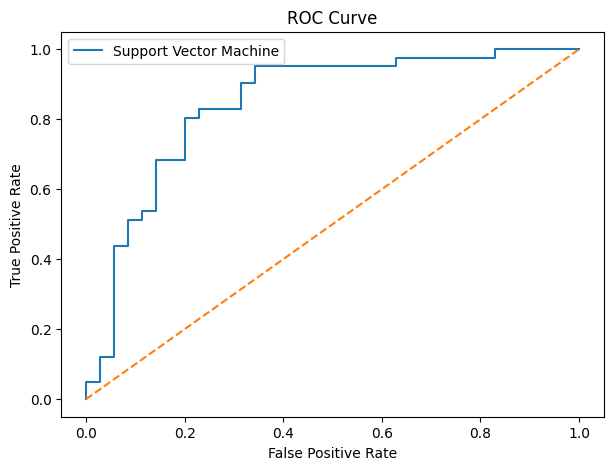

In [111]:
fpr, tpr, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Support Vector Machine")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Support Vector Machine urmărește separarea optimă a claselor printr-o frontieră de decizie cu marjă maximă. Modelul este, de asemenea, sensibil la scalarea caracteristicilor, astfel antrenarea a fost făcută pe date standardizate.

### 6.5 Decision Tree

In [112]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(random_state=42)

decision_tree.fit(X_train, y_train)

y_pred_dt = decision_tree.predict(X_test)
y_prob_dt = decision_tree.predict_proba(X_test)[:, 1]

In [113]:
dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt),
    "Recall": recall_score(y_test, y_pred_dt),
    "F1 Score": f1_score(y_test, y_pred_dt),
    "ROC-AUC": roc_auc_score(y_test, y_prob_dt)
}

results.append(dt_results)
pd.DataFrame([dt_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.724,0.738,0.756,0.747,0.721


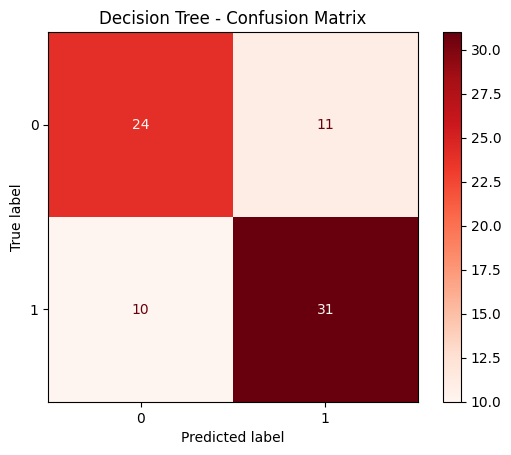

In [114]:
cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

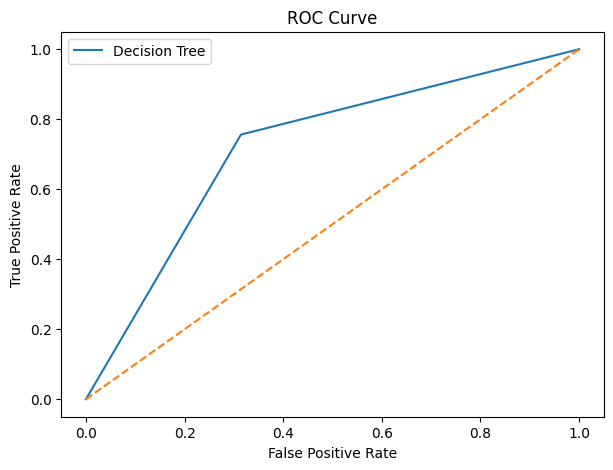

In [115]:
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Decision Tree construiește reguli de decizie pe baza caracteristicilor disponibile. Modelul nu necesită standardizarea datelor, însă poate fi predispus la overfitting în forma sa de bază.

### 6.6 Random Forest

In [116]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(random_state=42)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [117]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf),
    "ROC-AUC": roc_auc_score(y_test, y_prob_rf)
}

results.append(rf_results)
pd.DataFrame([rf_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.803,0.809,0.829,0.819,0.854


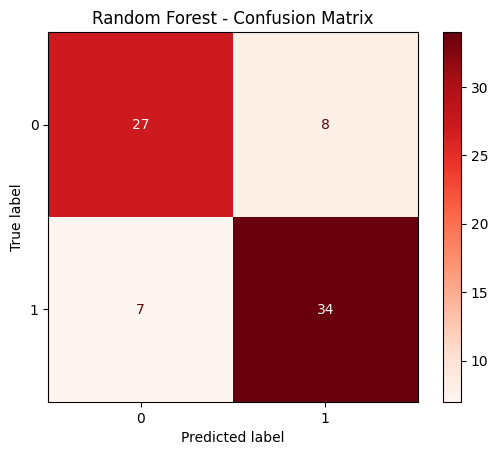

In [118]:
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Random Forest - Confusion Matrix")
plt.show()

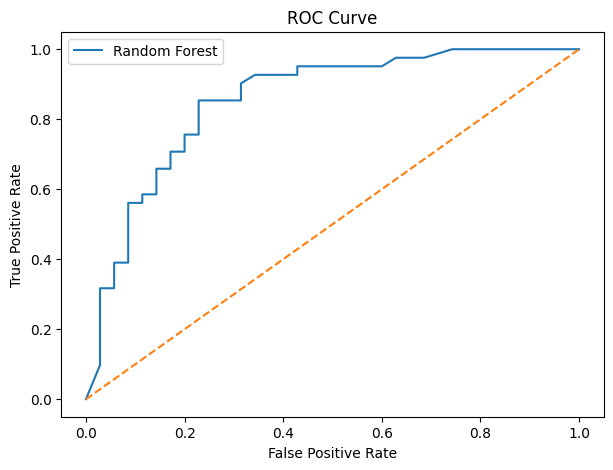

In [119]:
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Random Forest combină mai mulți arbori de decizie antrenați pe eșantioane diferite ale datelor, reducând riscul de overfitting specific unui singur arbore. În practică, este adesea unul dintre cele mai stabile modele pentru date tabelare.

### 6.7 Xtreme Gradient Boosting (XGBoost)

In [120]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(eval_metric="logloss",random_state=42)

xgboost_model.fit(X_train, y_train)

y_pred_xgb = xgboost_model.predict(X_test)
y_prob_xgb = xgboost_model.predict_proba(X_test)[:, 1]

In [121]:
xgb_results = {
    "Model": "Xtreme Gradient Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "Precision": precision_score(y_test, y_pred_xgb),
    "Recall": recall_score(y_test, y_pred_xgb),
    "F1 Score": f1_score(y_test, y_pred_xgb),
    "ROC-AUC": roc_auc_score(y_test, y_prob_xgb)
}

results.append(xgb_results)
pd.DataFrame([xgb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Xtreme Gradient Boosting,0.750,0.762,0.780,0.771,0.854


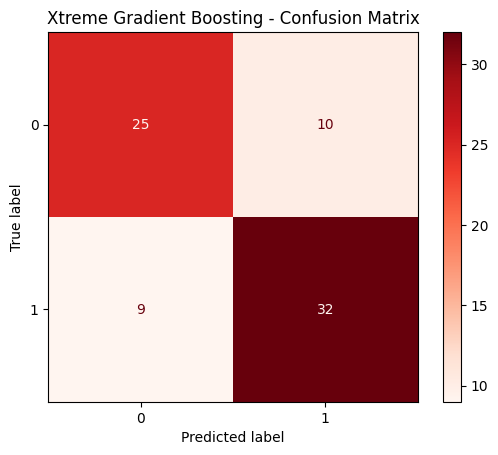

In [122]:
cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Xtreme Gradient Boosting - Confusion Matrix")
plt.show()

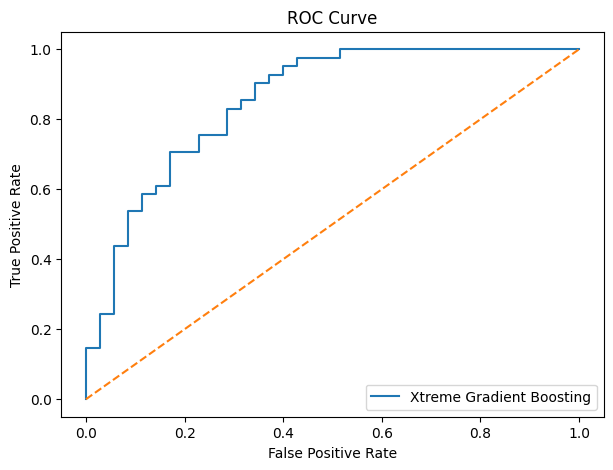

In [123]:
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Xtreme Gradient Boosting")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații 
Xtreme Gradient Boosting construiește succesiv arbori de decizie, fiecare model nou încercând să corecteze erorile celor anterioare. Este un algoritm puternic pentru date tabelare și poate obține performanțe foarte bune chiar și cu setări implicite.

### 6.8 Categorical Boosting (CatBoost)

In [124]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(verbose=0, random_state=42)

catboost_model.fit(X_train, y_train)

y_pred_cat = catboost_model.predict(X_test)
y_prob_cat = catboost_model.predict_proba(X_test)[:, 1]

y_pred_cat = y_pred_cat.astype(int)

In [125]:
cat_results = {
    "Model": "Categorical Boosting",
    "Accuracy": accuracy_score(y_test, y_pred_cat),
    "Precision": precision_score(y_test, y_pred_cat),
    "Recall": recall_score(y_test, y_pred_cat),
    "F1 Score": f1_score(y_test, y_pred_cat),
    "ROC-AUC": roc_auc_score(y_test, y_prob_cat)
}

results.append(cat_results)
pd.DataFrame([cat_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Categorical Boosting,0.776,0.773,0.829,0.800,0.868


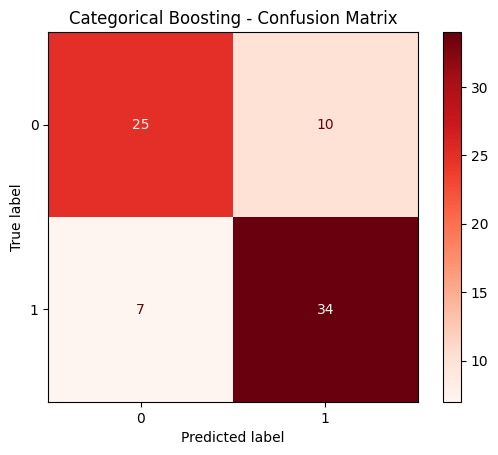

In [126]:
cm = confusion_matrix(y_test, y_pred_cat)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Categorical Boosting - Confusion Matrix")
plt.show()

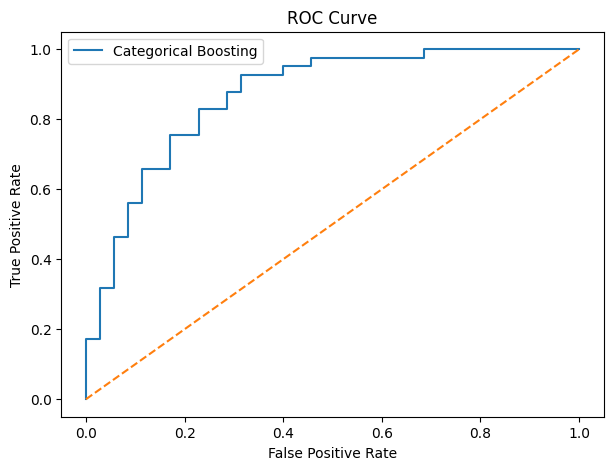

In [127]:
fpr, tpr, _ = roc_curve(y_test, y_prob_cat)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Categorical Boosting")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Categorical Boosting este un algoritm de boosting modern, făcut pentru performanță ridicată pe date tabelare. Deși este cunoscut pentru tratarea eficientă a variabilelor categoriale, poate oferi rezultate foarte bune și pe seturi de date deja numerice.

### 6.9 Explainable Boosting Machine (EBM)

In [128]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm_model = ExplainableBoostingClassifier(random_state=42)

ebm_model.fit(X_train, y_train)

y_pred_ebm = ebm_model.predict(X_test)
y_prob_ebm = ebm_model.predict_proba(X_test)[:, 1]

In [129]:
ebm_results = {
    "Model": "Explainable Boosting Machine",
    "Accuracy": accuracy_score(y_test, y_pred_ebm),
    "Precision": precision_score(y_test, y_pred_ebm),
    "Recall": recall_score(y_test, y_pred_ebm),
    "F1 Score": f1_score(y_test, y_pred_ebm),
    "ROC-AUC": roc_auc_score(y_test, y_prob_ebm)
}

results.append(ebm_results)
pd.DataFrame([ebm_results]).round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.803,0.825,0.805,0.815,0.884


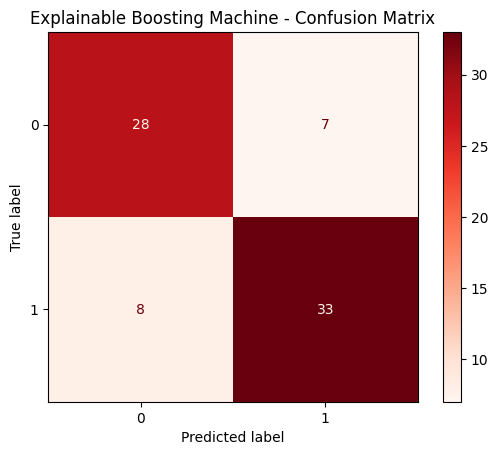

In [130]:
cm = confusion_matrix(y_test, y_pred_ebm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Reds")
plt.title("Explainable Boosting Machine - Confusion Matrix")
plt.show()

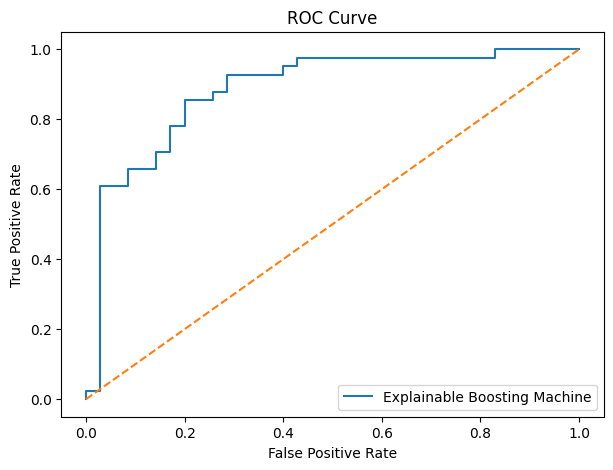

In [131]:
fpr, tpr, _ = roc_curve(y_test, y_prob_ebm)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Explainable Boosting Machine")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Observații
Explainable Boosting Machine combină performanța modelelor de boosting cu un nivel ridicat de interpretabilitate. Modelul este util în contexte în care acuratețea trebuie completată de probabilitatea explicării deciziilor.

## 7. Compararea modelelor de bază

In [132]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.803,0.825,0.805,0.815,0.884
1,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880
2,Logistic Regression,0.803,0.783,0.878,0.828,0.875
3,Categorical Boosting,0.776,0.773,0.829,0.800,0.868
4,Xtreme Gradient Boosting,0.750,0.762,0.780,0.771,0.854
5,Random Forest,0.803,0.809,0.829,0.819,0.854
6,Support Vector Machine,0.789,0.791,0.829,0.809,0.845
7,K-Nearest Neighbors,0.789,0.791,0.829,0.809,0.829
8,Decision Tree,0.724,0.738,0.756,0.747,0.721


In [133]:
top_5_models = results_df.head(5).copy()

top_5_models.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.803,0.825,0.805,0.815,0.884
1,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880
2,Logistic Regression,0.803,0.783,0.878,0.828,0.875
3,Categorical Boosting,0.776,0.773,0.829,0.800,0.868
4,Xtreme Gradient Boosting,0.750,0.762,0.780,0.771,0.854


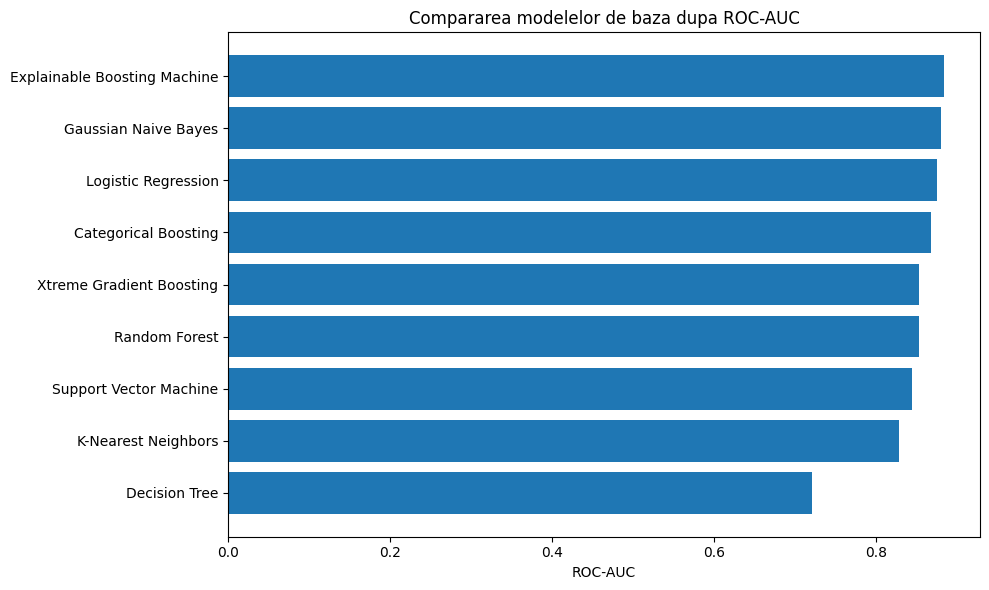

In [134]:
plt.figure(figsize=(10, 6))

plt.barh(
    results_df["Model"],
    results_df["ROC-AUC"]
)

plt.xlabel("ROC-AUC")
plt.title("Compararea modelelor de baza dupa ROC-AUC")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

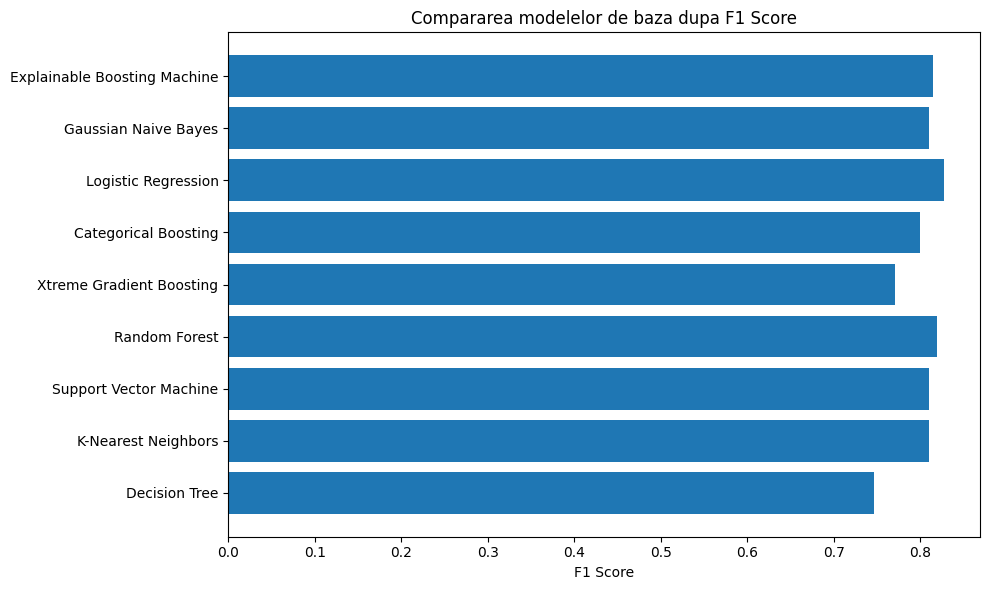

In [135]:
plt.figure(figsize=(10, 6))

plt.barh(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.xlabel("F1 Score")
plt.title("Compararea modelelor de baza dupa F1 Score")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Observații

Pentru realizarea clasamentului final al modelelor de bază a fost utilizată metrica **ROC-AUC**, deoarece aceasta oferă o evaluare mai detaliată decât acuratețea în problemele de clasificare binară. ROC-AUC măsoară capacitatea modelului de a separa corect două clase pentru mai multe praguri de decizie, fiind o alegere potrivită în context medical, unde diferențierea corectă între pacienții cu risc și cei fără risc este importantă.

Pe baza rezultatelor obținute, primele 5 modele selectate pentru etapa de ajustare a hiperparametrilor sunt:

1. Explainable Boosting Machine
2. Gaussian Naive Bayes
3. Logistic Regression
4. Categorical Boosting
5. Xtreme Gradient Boosting

Aceste modele au cele mai bune valori ROC-AUC dintre clasificatorii testați și vor fi analizate în continuare într-o etapă de optimizare.

## 8. Ajustarea hiperparametrilor

În această etapă sunt ajustați hiperparametrii celor mai bune 5 modele obținute în etapa de bază. Se păstrează aceeași metrică principală, ROC-AUC, pentru a menține o comparație coerentă cu rezultatele anterioare.

Pentru modelele cu un spațiu redus de căutare, precum **Gaussian Naive Bayes** și **Logistic Regression**, este utilizat **GridSearchCV**. Pentru modelele mai complexe, precum **Explainable Boosting Machine**, **Categorical Boosting** și **Xtreme Gradient Boosting**, este utilizat **BayesSearchCV**, deoarece permite explorarea mai eficientă a combinațiilor de hiperparametri.

Intervalele de valori au fost alese astfel încât să acopere variante mai simple și mai complexe ale fiecărui model, fără a face căutarea inutil de costisitoare.

In [136]:
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer

tuned_results = []
best_models = {}

In [137]:
def evaluate_tuned_model(model_name, model, X_test_data, y_test):
    y_pred = model.predict(X_test_data)
    y_prob = model.predict_proba(X_test_data)[:,1]

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    tuned_results.append(result)
    best_models[model_name] = model

    return pd.DataFrame([result]).round(4)

### 8.1 Ajustare hiperparametri: Explainable Boosting Machine

In [138]:
ebm_search = BayesSearchCV(
    estimator=ExplainableBoostingClassifier(random_state=42),
    search_spaces={
        "learning_rate": Real(0.01, 0.1, prior="log-uniform"),
        "max_bins": Integer(64, 256),
        "interactions": Integer(0, 10)
    },
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42
)

ebm_search.fit(X_train, y_train)

print("Cei mai buni hiperparametri:")
print(ebm_search.best_params_)

print("\nCel mai bun scor ROC-AUC in validare:")
print(round(ebm_search.best_score_, 4))

Cei mai buni hiperparametri:
OrderedDict({'interactions': 1, 'learning_rate': 0.010031967457313797, 'max_bins': 121})

Cel mai bun scor ROC-AUC in validare:
0.922


In [139]:
best_ebm = ebm_search.best_estimator_

evaluate_tuned_model(
    "Explainable Boosting Machine",
    best_ebm,
    X_test,
    y_test
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.816,0.829,0.829,0.829,0.891


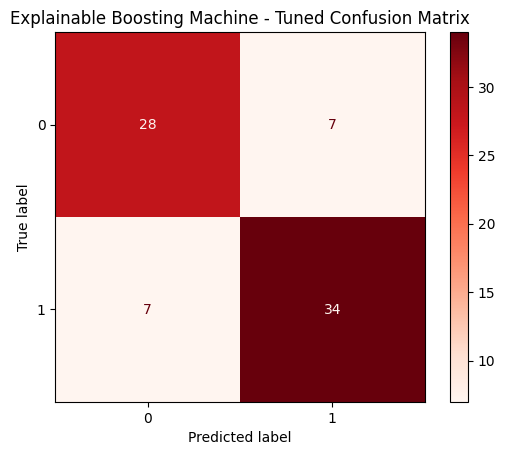

In [140]:
y_pred_ebm_tuned = best_ebm.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_ebm_tuned,
    cmap="Reds"
)

plt.title("Explainable Boosting Machine - Tuned Confusion Matrix")
plt.show()

### Observații

Pentru modelul **Explainable Boosting Machine** a fost utilizat **BayesSearchCV**, deoarece optimizarea exhaustivă a tuturor combinațiilor posibile ar fi mai costisitoare computațional. Au fost ajustați hiperparametrii `learning_rate`, `max_bins` și `interactions`, care influențează viteza de învățare, granularitatea discretizării și nivelul interacțiunilor dintre variabile.

Intervalele de valori au fost alese astfel încât să permită testarea unor variante mai simple și mai complexe ale modelului, menținând în același timp un timp rezonabil de execuție.

### 8.2 Ajustare hiperparametri: Gaussian Naive Bayes

In [141]:
gnb_param_grid = { "var_smoothing": np.logspace(-12, -6, 7)}

gnb_grid = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=gnb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

gnb_grid.fit(X_train_scaled, y_train)

print("Cei mai buni hiperparametri:")
print(gnb_grid.best_params_)

print("\nCel mai bun scor ROC-AUC in validare:")
print(round(gnb_grid.best_score_, 4))

Cei mai buni hiperparametri:
{'var_smoothing': np.float64(1e-12)}

Cel mai bun scor ROC-AUC in validare:
0.8988


In [142]:
best_gnb = gnb_grid.best_estimator_

evaluate_tuned_model(
    "Gaussian Naive Bayes",
    best_gnb,
    X_test_scaled,
    y_test
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880


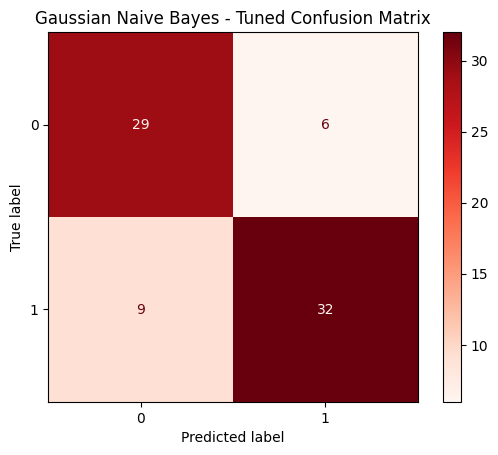

In [143]:
y_pred_gnb_tuned = best_gnb.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_gnb_tuned,
    cmap="Reds"
)

plt.title("Gaussian Naive Bayes - Tuned Confusion Matrix")
plt.show()

### Observații

Pentru modelul **Gaussian Naive Bayes** a fost utilizat **GridSearchCV**, deoarece acesta are un număr redus de hiperparametri relevanți, iar spațiul de căutare este restrâns. A fost ajustat parametrul `var_smoothing`, care influențează stabilitatea estimării varianței și poate îmbunătăți robustețea modelului în prezența valorilor foarte mici.

Valorile testate au fost alese pe scară logaritmică pentru a analiza eficient mai multe ordine de mărime ale acestui hiperparametru.

### 8.3 Ajustare hiperparametri: Logistic Regression

In [144]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=2000, random_state=42),
    param_grid=lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)

print("Cei mai buni hiperparametri:")
print(lr_grid.best_params_)

print("\nCel mai bun scor ROC-AUC in validare:")
print(round(lr_grid.best_score_, 4))

Cei mai buni hiperparametri:
{'C': 0.01, 'solver': 'lbfgs'}

Cel mai bun scor ROC-AUC in validare:
0.9119


In [145]:
best_lr = lr_grid.best_estimator_

evaluate_tuned_model(
    "Logistic Regression",
    best_lr,
    X_test_scaled,
    y_test
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.816,0.787,0.902,0.841,0.879


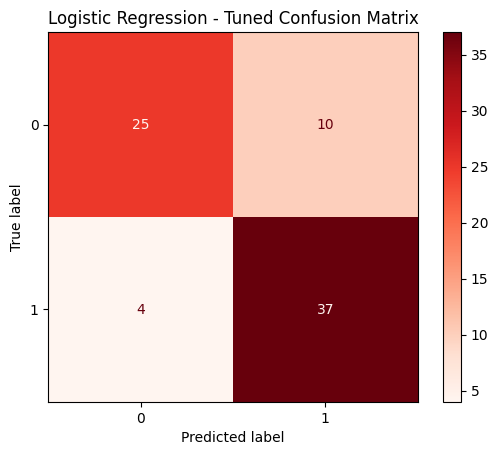

In [146]:
y_pred_lr_tuned = best_lr.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr_tuned,
    cmap="Reds"
)

plt.title("Logistic Regression - Tuned Confusion Matrix")
plt.show()

### Observații

Pentru modelul **Logistic Regression** a fost utilizat **GridSearchCV**, deoarece numărul hiperparametrilor relevanți este redus, iar toate combinațiile pot fi evaluate eficient. Au fost ajustate valorile parametrului `C`, care controlează intensitatea regularizării, precum și algoritmul de optimizare (`solver`).

Valorile alese pentru `C` acoperă atât variante cu regularizare mai puternică, cât și variante mai permisive. Modelul a fost antrenat pe date standardizate, deoarece performanța regresiei logistice este influențată de scara caracteristicilor.

### 8.4 Ajustare hiperparametri: Categorical Boosting (CatBoost)

In [147]:
cat_search = BayesSearchCV(
    estimator=CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    search_spaces={
        "depth": Integer(4, 10),
        "learning_rate": Real(0.01, 0.1, prior="log-uniform"),
        "iterations": Integer(100, 400)
    },
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42
)

cat_search.fit(X_train, y_train)

print("Cei mai buni hiperparametri:")
print(cat_search.best_params_)

print("\nCel mai bun scor ROC-AUC in validare:")
print(round(cat_search.best_score_, 4))

Cei mai buni hiperparametri:
OrderedDict({'depth': 4, 'iterations': 325, 'learning_rate': 0.01})

Cel mai bun scor ROC-AUC in validare:
0.9222


In [148]:
best_cat = cat_search.best_estimator_

evaluate_tuned_model(
    "Categorical Boosting",
    best_cat,
    X_test,
    y_test
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Categorical Boosting,0.816,0.800,0.878,0.837,0.876


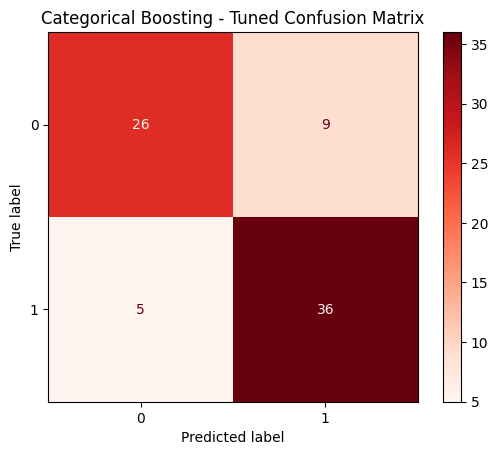

In [149]:
y_pred_cat_tuned = best_cat.predict(X_test)
y_pred_cat_tuned = y_pred_cat_tuned.astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_cat_tuned,
    cmap="Reds"
)

plt.title("Categorical Boosting - Tuned Confusion Matrix")
plt.show()

### Observații

Pentru modelul **Categorical Boosting** a fost utilizat **BayesSearchCV**, deoarece spațiul hiperparametrilor este mai extins, iar căutarea exhaustivă ar necesita un timp mai mare de execuție. Au fost ajustate adâncimea arborilor (`depth`), rata de învățare (`learning_rate`) și numărul de iterații (`iterations`).

Intervalele alese permit testarea unor modele mai simple și mai complexe, urmărind obținerea unui echilibru între performanță și capacitatea de generalizare pe date noi.

### 8.5 Ajustare hiperparametri: Xtreme Gradient Boosting (XGBoost)

In [150]:
xgb_search = BayesSearchCV(
    estimator=XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ),
    search_spaces={
        "n_estimators": Integer(100, 400),
        "max_depth": Integer(3, 8),
        "learning_rate": Real(0.01, 0.1, prior="log-uniform"),
        "subsample": Real(0.7, 1.0)
    },
    n_iter=20,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

print("Cei mai buni hiperparametri:")
print(xgb_search.best_params_)

print("\nCel mai bun scor ROC-AUC in validare:")
print(round(xgb_search.best_score_, 4))

Cei mai buni hiperparametri:
OrderedDict({'learning_rate': 0.06303089031548757, 'max_depth': 5, 'n_estimators': 258, 'subsample': 0.9147139786321099})

Cel mai bun scor ROC-AUC in validare:
0.9163


In [151]:
best_xgb = xgb_search.best_estimator_

evaluate_tuned_model(
    "Xtreme Gradient Boosting",
    best_xgb,
    X_test,
    y_test
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Xtreme Gradient Boosting,0.763,0.767,0.805,0.786,0.854


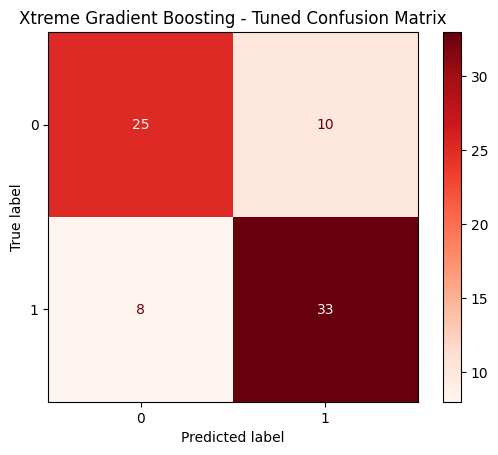

In [152]:
y_pred_xgb_tuned = best_xgb.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb_tuned,
    cmap="Reds"
)

plt.title("Xtreme Gradient Boosting - Tuned Confusion Matrix")
plt.show()

### Observații

Pentru modelul **Xtreme Gradient Boosting** a fost utilizat **BayesSearchCV**, deoarece modelul are mai mulți hiperparametri importanți, iar căutarea exhaustivă ar deveni costisitoare. Au fost ajustate numărul de arbori (`n_estimators`), adâncimea maximă (`max_depth`), rata de învățare (`learning_rate`) și proporția observațiilor folosite la fiecare iterație (`subsample`).

Intervalele selectate permit testarea unor configurații mai conservative și a unor configurații mai complexe, urmărind un echilibru între performanță și capacitatea de generalizare.

## 9. Compararea modelelor perfecționate

In [153]:
tuned_df = pd.DataFrame(tuned_results).sort_values(
    by="ROC-AUC",
    ascending=False
)

tuned_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Explainable Boosting Machine,0.816,0.829,0.829,0.829,0.891
1,Gaussian Naive Bayes,0.803,0.842,0.780,0.810,0.880
2,Logistic Regression,0.816,0.787,0.902,0.841,0.879
3,Categorical Boosting,0.816,0.800,0.878,0.837,0.876
4,Xtreme Gradient Boosting,0.763,0.767,0.805,0.786,0.854


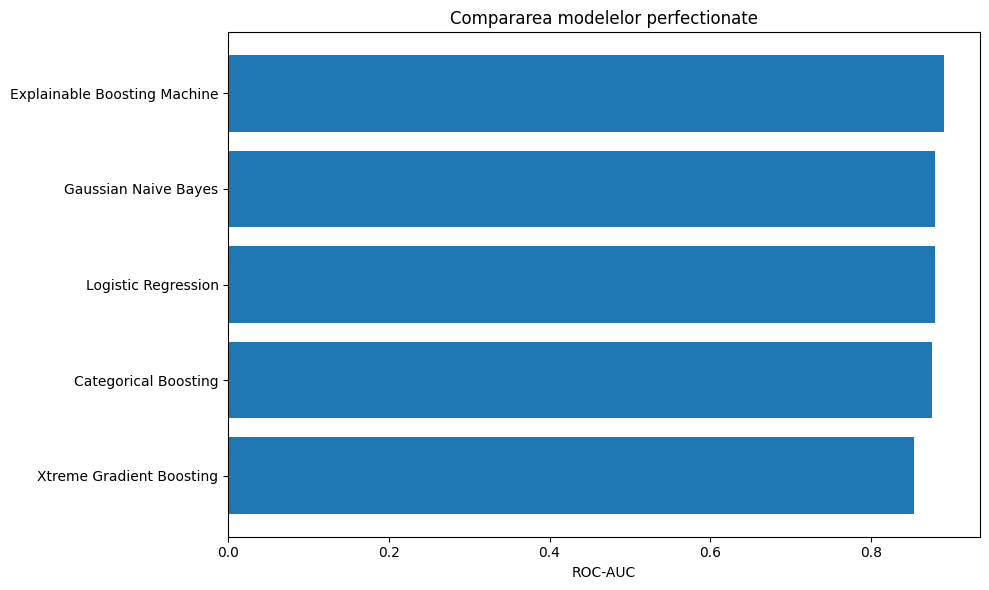

In [154]:
plt.figure(figsize=(10, 6))

plt.barh(
    tuned_df["Model"],
    tuned_df["ROC-AUC"]
)

plt.xlabel("ROC-AUC")
plt.title("Compararea modelelor perfectionate")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [155]:
best_final_model_name = tuned_df.loc[0, "Model"]
best_final_model_name

'Explainable Boosting Machine'

### Observații

După ajustarea hiperparametrilor, cel mai bun scor **ROC-AUC** a fost obținut de **Explainable Boosting Machine** (`0.891`), urmat de **Gaussian Naive Bayes** (`0.880`) și **Logistic Regression** (`0.879`).

Rezultatele indică faptul că modelul **Explainable Boosting Machine** oferă cel mai bun echilibru între performanța predictivă și capacitatea de separare a claselor. Un avantaj important al acestui model este nivelul ridicat de interpretabilitate, aspect deosebit de relevant într-un context medical.

Pe baza acestor rezultate, **Explainable Boosting Machine** va fi considerat modelul principal în etapele următoare de analiză și explicabilitate.

## 10. Curbele de învățare
În continuare este analizat comportamentul celor mai bune 5 modele selectate după etapa de ajustare a hiperparametrilor. Curbele de învățare evidențiază evoluția performanței pe măsură ce crește numărul de observații folosite la antrenare și permit compararea scorurilor de antrenare cu cele de validare.

Prin intermediul acestor grafice pot fi identificate situații de overfitting, underfitting sau modele care generalizează bine pe date noi. Pentru evaluare este utilizată metrica ROC-AUC, aceeași metrică folosită în etapele anterioare, pentru a păstra coerența comparațiilor.


In [156]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, model_name, X_data, y_data):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator=model,
        X=X_data,
        y=y_data,
        cv=5,
        scoring="roc_auc",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    valid_mean = valid_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, marker="o", label="Train Score")
    plt.plot(train_sizes, valid_mean, marker="o", label="Validation Score")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Numar exemple de antrenare")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### 10.1 Explainable Boosting Machine

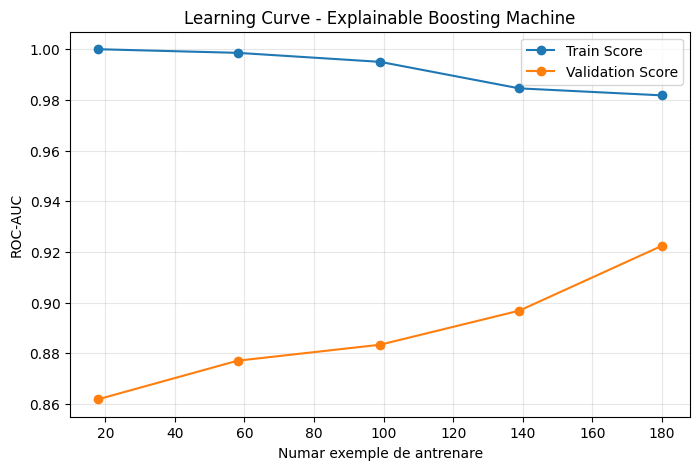

In [157]:
plot_learning_curve(
    best_models["Explainable Boosting Machine"],
    "Explainable Boosting Machine",
    X_train,
    y_train
)

### Observații

Scorul de antenare rămâne foarte ridicat, în timp ce scorul de validare este semnificativ mai mic, deși crește treptat odată cu mai multe date. Acest comportament indică tendințe de overfitting, însă modelul își îmbunătățește generalizarea pe măsură ce crește setul de antrenare.

### 10.2 Gaussian Naive Bayes

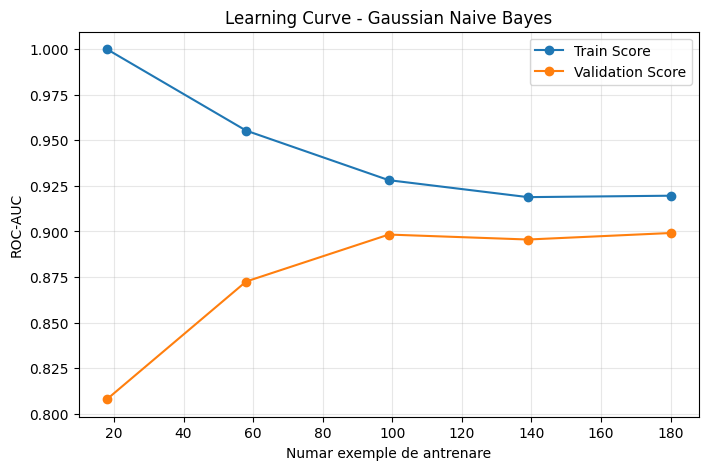

In [158]:
plot_learning_curve(
    best_models["Gaussian Naive Bayes"],
    "Gaussian Naive Bayes",
    X_train_scaled,
    y_train
)

### Observații

Diferența dintre scorul de antrenare și cel de validare este moderată și se reduce pe măsură ce cresc datele de antrenare. Modelul prezintă o generalizare bună și un risc redus de overfitting comparativ cu modelele mai complexe.

### 10.3 Logistic Regression

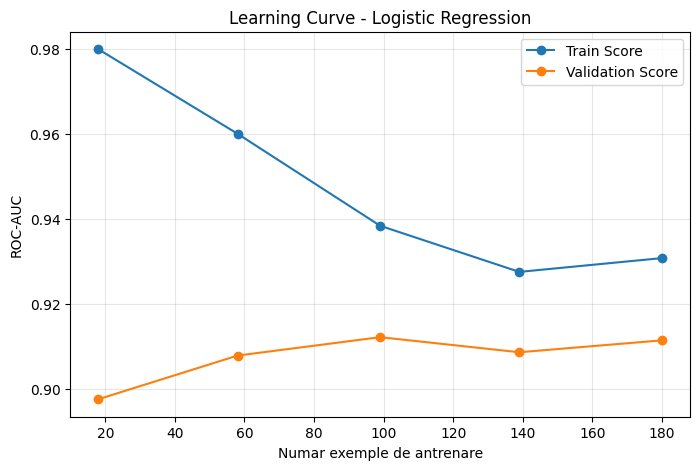

In [159]:
plot_learning_curve(
    best_models["Logistic Regression"],
    "Logistic Regression",
    X_train_scaled,
    y_train
)

### Observații

Curbele de antrenare și validare sunt relativ apropiate, iar scorurile se stabilizează la valori bune. Acest rezultat sugerează un model echilibrat, cu generalizare bună și fără semne importante de overfitting.  

### 10.4 Categorical Boosting

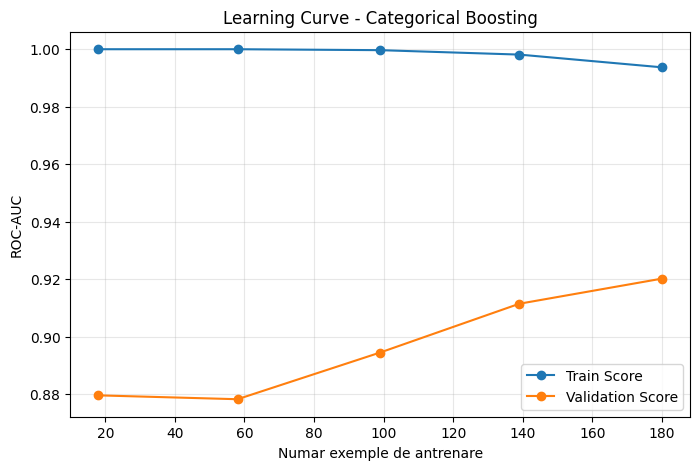

In [160]:
plot_learning_curve(
    best_models["Categorical Boosting"],
    "Categorical Boosting",
    X_train,
    y_train
)

### Observații

Scorul de antrenare este foarte ridicat, iar scorul de validare crește progresiv odată cu volumul de date. Diferența dintre curbe indică existența unui anumit grad de overfitting, specific modelelor de boosting puternice.

### 10.5 Xtreme Gradient Boosting

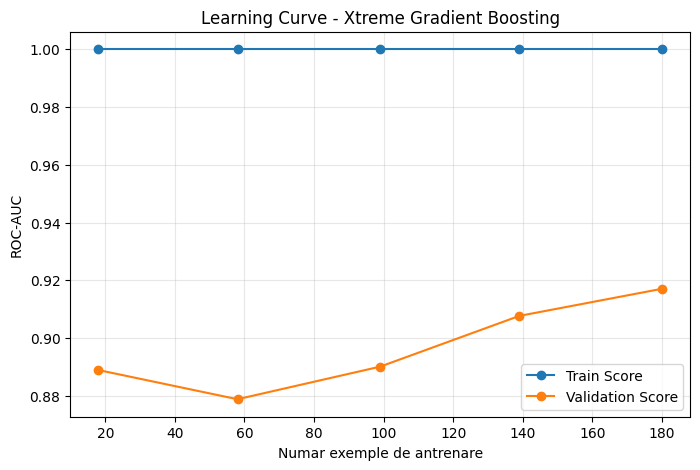

In [161]:
plot_learning_curve(
    best_models["Xtreme Gradient Boosting"],
    "Xtreme Gradient Boosting",
    X_train,
    y_train
)

### Observații

Modelul obține scor maxim pe antrenare, însă scorul de validare rămâne mai jos, chiar dacă se îmbunătățește treptat. Acest comportament indică overfitting mai pronunțat decât în cazul modelelor mai simple.

### Concluzii ale analizei curbelor de învățare

Curbele de învățare evidențiază diferențe clare între modelele analizate. Modelele bazate pe boosting, precum **Explainable Boosting Machine**, **Categorical Boosting** și **Xtreme Gradient Boosting**, obțin scoruri foarte ridicate pe datele de antrenare, însă diferența față de scorurile de validare indică existența unor tendințe de overfitting.

În schimb, **Gaussian Naive Bayes** și **Logistic Regression** prezintă curbe mai apropiate între antrenare și validare, ceea ce sugerează o capacitate mai bună de generalizare și un comportament mai stabil pe date noi.

Se observă, de asemenea, că scorurile de validare cresc odată cu mărirea setului de antrenare, ceea ce indică faptul că modelele beneficiază de date suplimentare și își pot îmbunătăți performanța în prezența unui volum mai mare de date.

În ansamblu, modelul **Explainable Boosting Machine** rămâne cel mai performant, însă **Logistic Regression** și **Gaussian Naive Bayes** oferă un compromis foarte bun între performanță predictivă și stabilitate.

## 11. Explicabilitatea modelelor prin SHAP

În această secțiune sunt analizate primele 3 modele perfecționate, utilizând SHAP pentru interpretarea predicțiilor. Analiza include atât explicații globale, prin care este evaluată importanța caracteristicilor la nivelul întregului set de testare, cât și explicații locale, pentru a observa modul în care anumite variabile influențează o predicție individuală.

In [162]:
import shap

X_test_df = X_test.copy()
X_train_df = X_train.copy()

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)

shap.initjs()

### 11.1 Analiza SHAP pentru Explainable Boosting Machine

In [163]:
explainer_ebm = shap.Explainer(best_ebm.predict_proba, X_train_df)

shap_values_ebm = explainer_ebm(X_test_df)

shap_values_ebm_class1 = shap_values_ebm[:, :, 1]

C:\Users\Denisa\AppData\Local\Temp\ipykernel_5860\2258093036.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


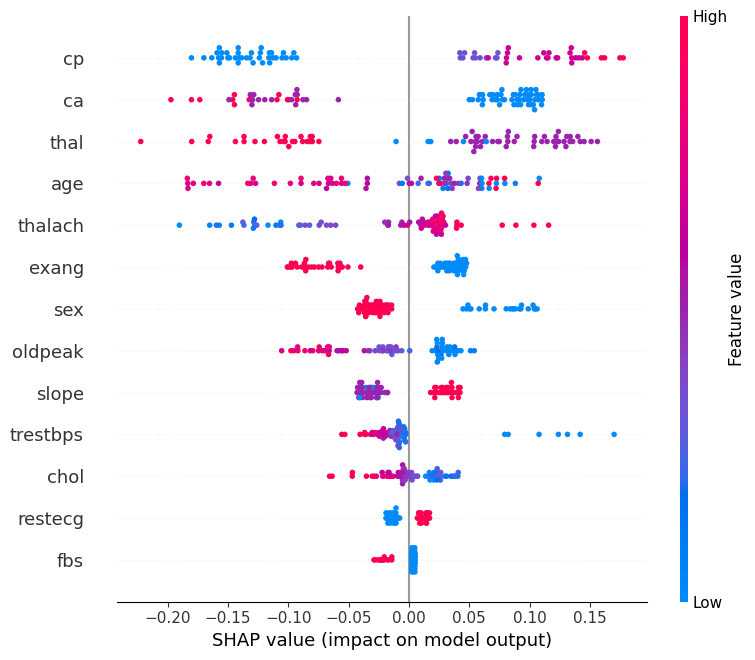

In [164]:
shap.summary_plot(
    shap_values_ebm_class1,
    X_test_df
)

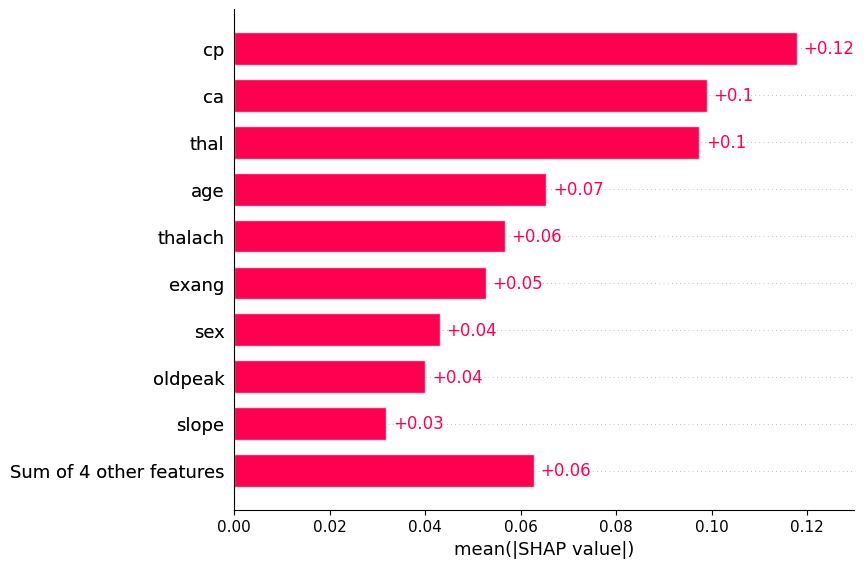

In [165]:
shap.plots.bar(shap_values_ebm_class1)

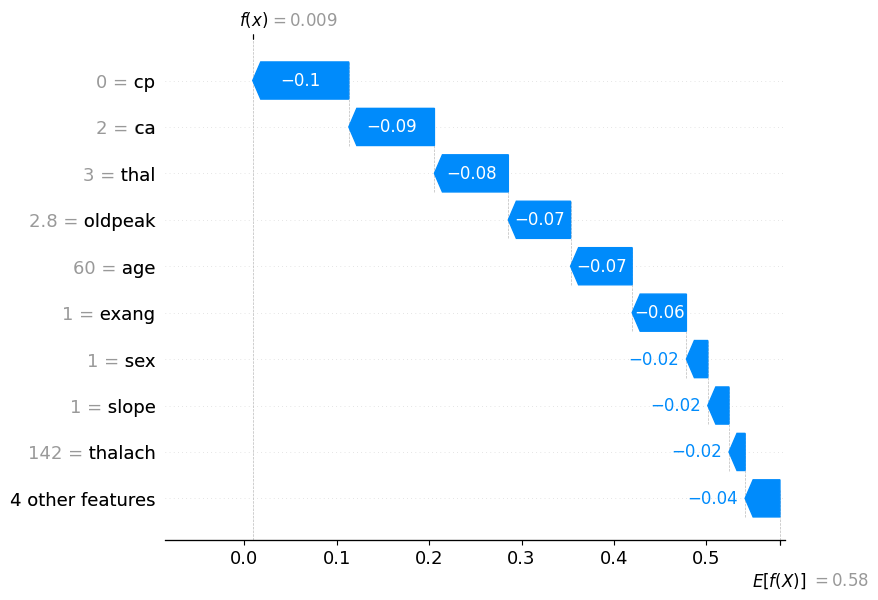

In [166]:
sample_index = 0

shap.plots.waterfall(
    shap_values_ebm_class1[sample_index]
)

In [167]:
shap.force_plot(
    shap_values_ebm_class1[sample_index].base_values,
    shap_values_ebm_class1[sample_index].values,
    X_test_df.iloc[sample_index]
)

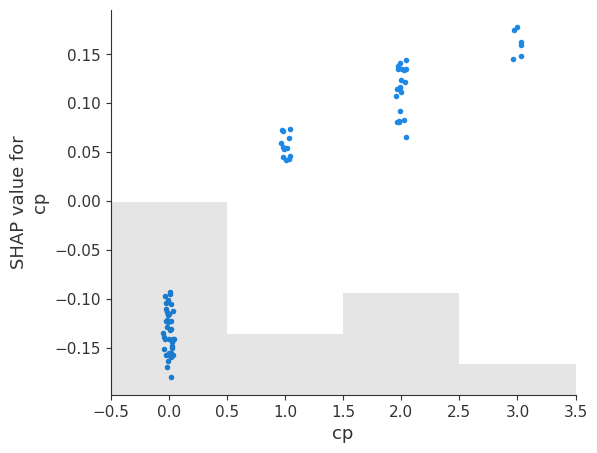

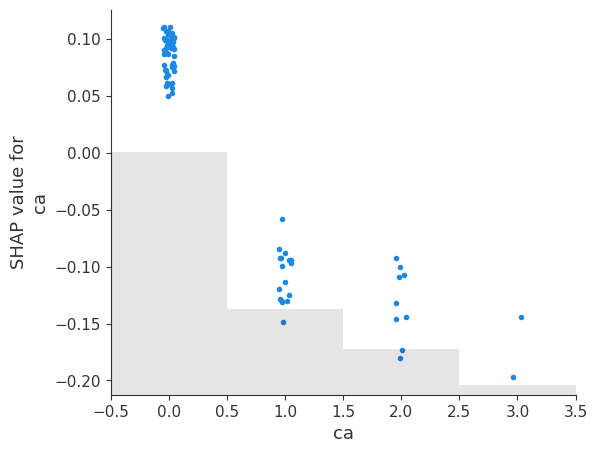

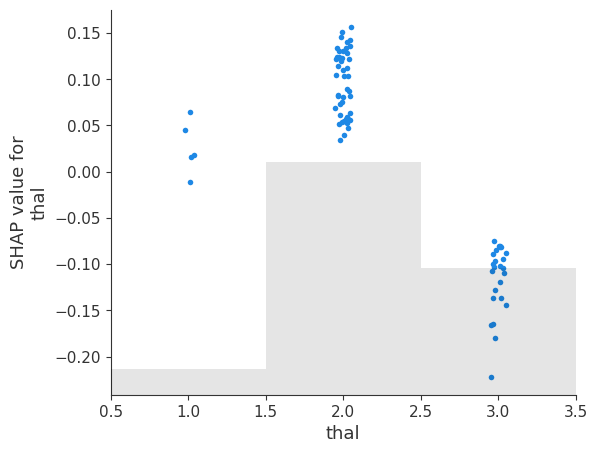

In [168]:
shap.plots.scatter(shap_values_ebm_class1[:, "cp"])
shap.plots.scatter(shap_values_ebm_class1[:, "ca"])
shap.plots.scatter(shap_values_ebm_class1[:, "thal"])

### Observații

Graficele scatter confirmă faptul că variabilele `cp`, `ca` și `thal` au o influență majoră asupra predicțiilor modelului.

Pentru variabila `cp`, valorile mici (0) sunt asociate cu valori SHAP negative, ceea ce reduce probabilitatea clasei pozitive. În schimb, valorile mai mari (2 și 3) determină contribuții pozitive importante, crescând scorul predicției.

În cazul variabilei `ca`, valorile mici (0) tind să aibă contribuții pozitive, în timp ce valorile mai mari (1, 2, 3) împing predicția în jos, având valori SHAP negative.

Pentru variabila `thal`, valoarea 2 este asociată cu contribuții pozitive semnificative, în timp ce valoarea 3 determină contribuții negative și reduce scorul predicției.

Rezultatele arată că modelul utilizează aceste caracteristici pentru a diferenția clar observațiile aparținând celor două clase.

### 11.2 Analiza SHAP pentru Gaussian Naive Bayes

In [172]:
explainer_gnb = shap.Explainer(
    best_gnb.predict_proba,
    X_train_scaled_df
)

shap_values_gnb = explainer_gnb(X_test_scaled_df)

shap_values_gnb_class1 = shap_values_gnb[:, :, 1]

c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GaussianNB was fitted with

C:\Users\Denisa\AppData\Local\Temp\ipykernel_5860\1832740761.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_gnb_class1, X_test_scaled_df)


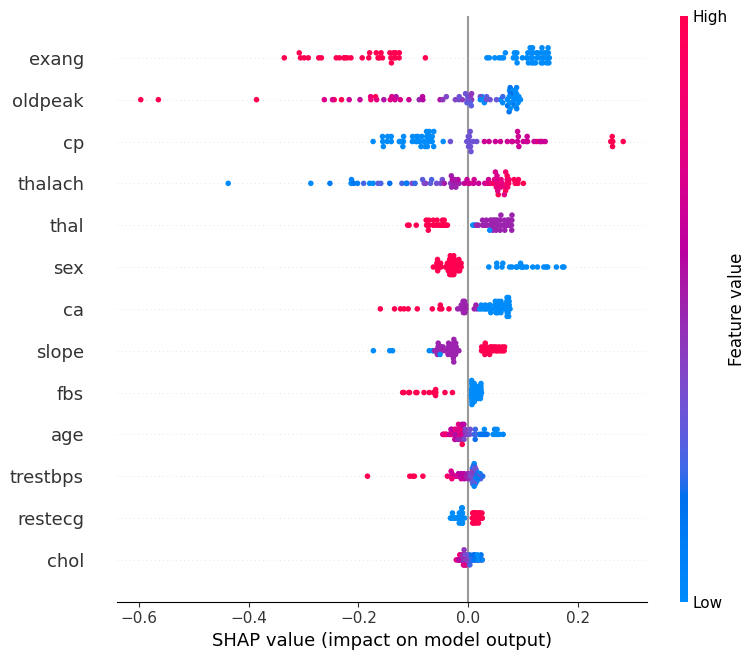

In [173]:
shap.summary_plot(shap_values_gnb_class1, X_test_scaled_df)

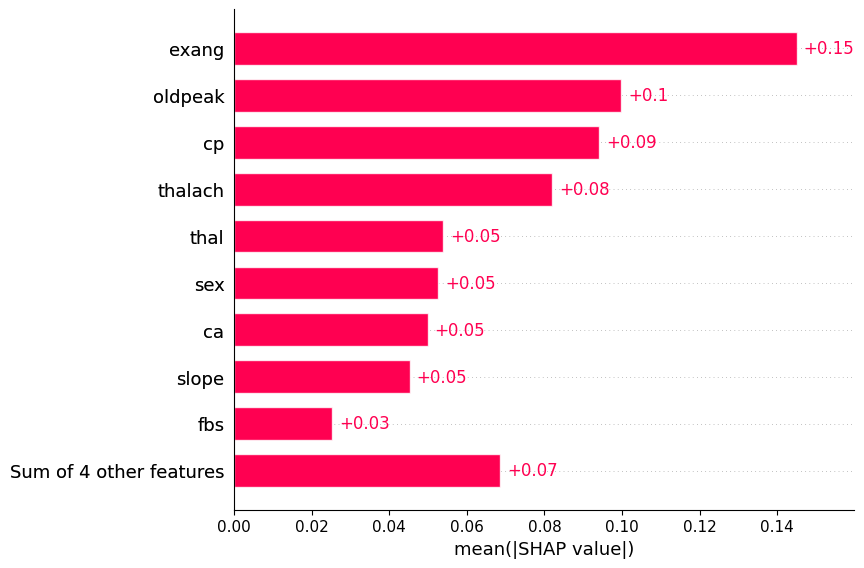

In [174]:
shap.plots.bar(shap_values_gnb_class1)

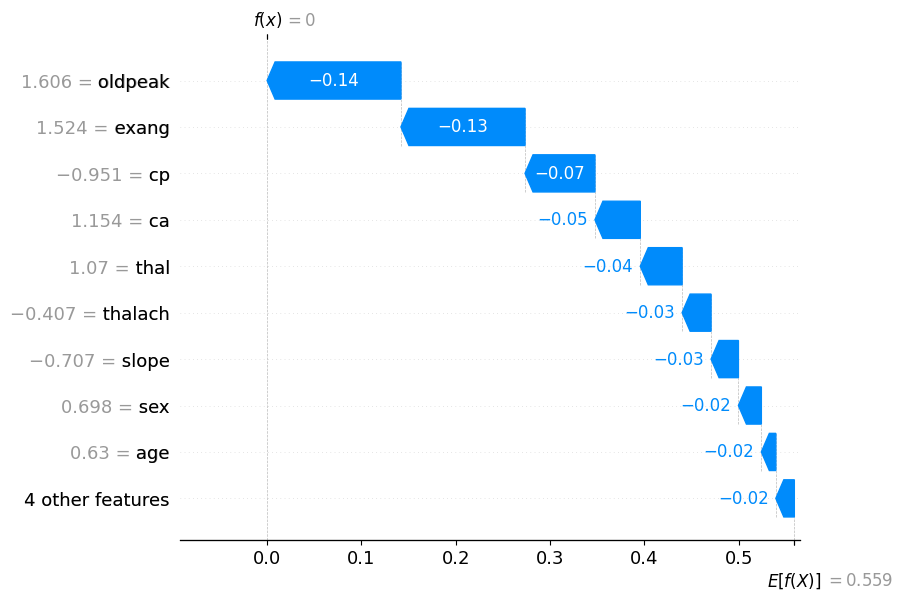

In [175]:
sample_index = 0

shap.plots.waterfall(shap_values_gnb_class1[sample_index])

In [176]:
shap.force_plot(
    shap_values_gnb_class1[sample_index].base_values,
    shap_values_gnb_class1[sample_index].values,
    X_test_scaled_df.iloc[sample_index]
)

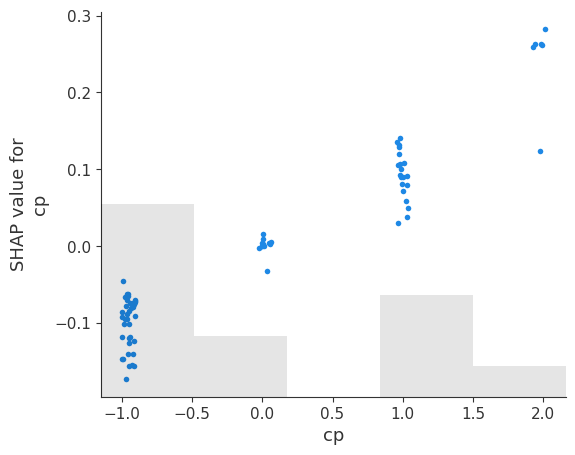

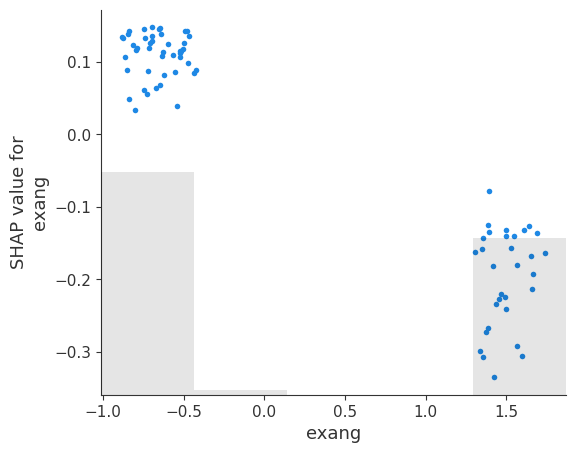

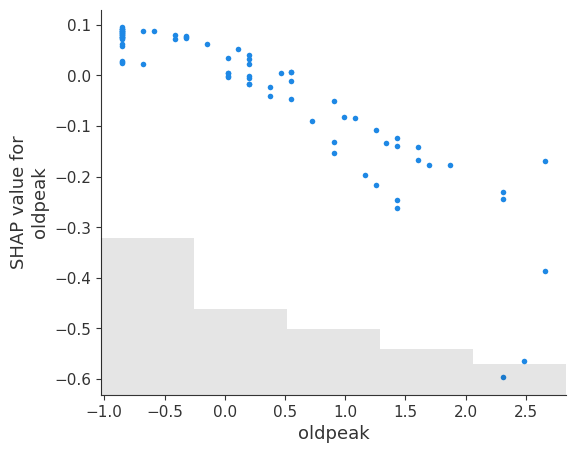

In [178]:
shap.plots.scatter(shap_values_gnb_class1[:, "cp"])
shap.plots.scatter(shap_values_gnb_class1[:, "exang"])
shap.plots.scatter(shap_values_gnb_class1[:, "oldpeak"])

### Observații

Analiza globală realizată prin summary plot și bar plot arată că cele mai importante 3 caracteristici pentru modelul **Gaussian Naive Bayes** sunt **exang**, **oldpeak** și **cp**, urmate de **thalach**.

Pentru variabila `exang`, valorile ridicate tind să reducă scorul predicției,având contribuții negative importante. Valorile mici sunt asociate mai frecvent cu influențe pozitive asupra clasei pozitive.

În cazul variabilei `oldpeak`, valorile mari determină contribuții negative semnificative, în timp ce valorile mici sau moderate tind să împingă predicția în sus.

Pentru variabila `cp`, valorile mici sunt asociate cu valori SHAP negative iar valorile mai mari cresc scorul predicției și favorizează clasa pozitivă.

Analiza locală realizată prin waterfall plot și force plot pentru observația selectată arată că valorile `oldpeak = 1.606`, `exang = 1.524` și `ca = 1.154` au contribuit semnificativ la scăderea scorului final al modelului. Predicția finală a fost astfel împinsă spre clasa negativă.

Rezultate confirmă faptul că modelul Gaussian Naive Bayes utilizează în principal variabile clinice relevante pentru diferențierea observațiilor aparținând celor două clase.

### 11.3 Analiza SHAP pentru Logistic Regression

In [179]:
explainer_lr = shap.Explainer(best_lr.predict_proba, X_train_scaled_df)

shap_values_lr = explainer_lr(X_test_scaled_df)

shap_values_lr_class1 = shap_values_lr[:, :, 1]

c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\Denisa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names

C:\Users\Denisa\AppData\Local\Temp\ipykernel_5860\4167282749.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_lr_class1, X_test_scaled_df)


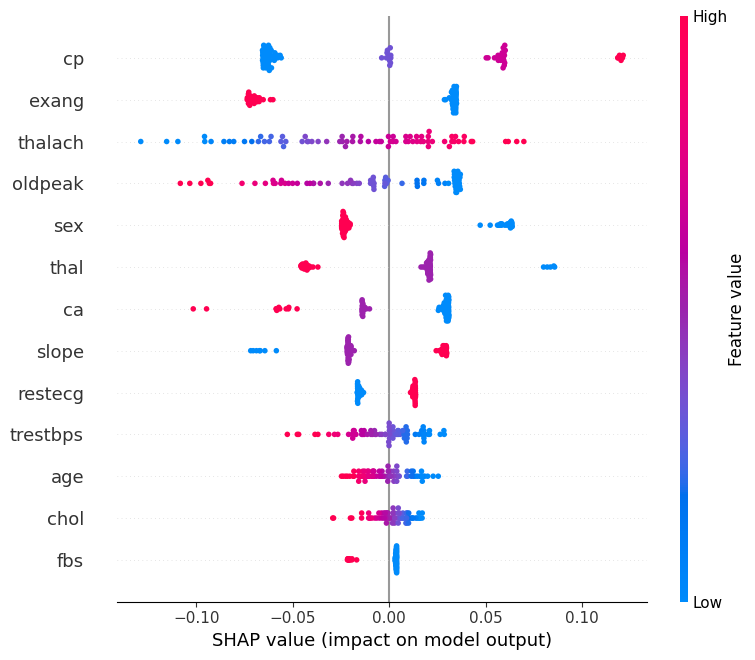

In [180]:
shap.summary_plot(shap_values_lr_class1, X_test_scaled_df)

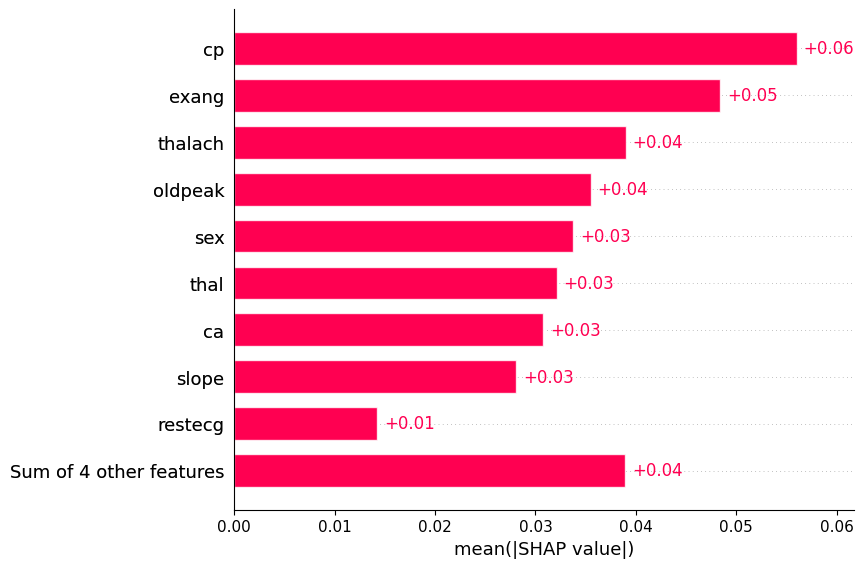

In [181]:
shap.plots.bar(shap_values_lr_class1)

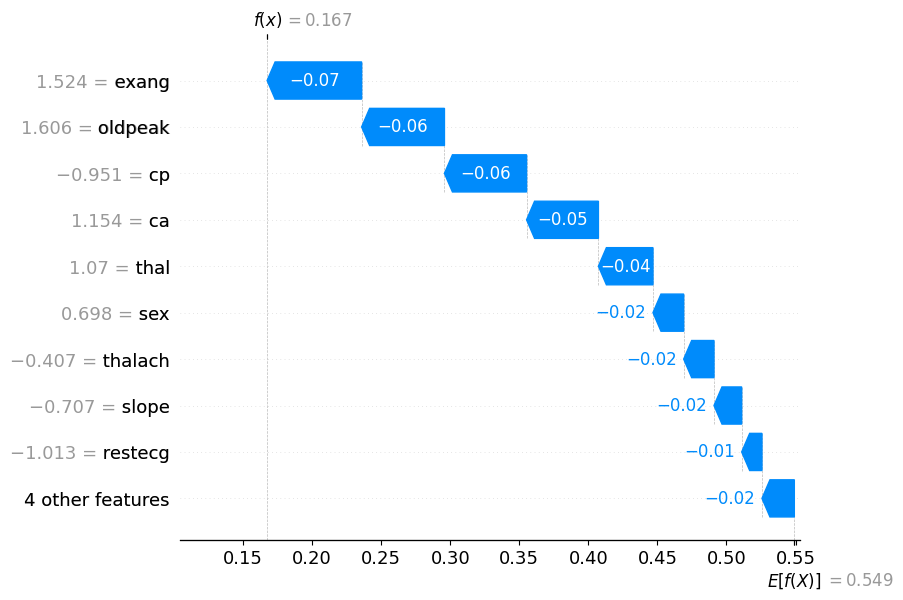

In [182]:
sample_index = 0

shap.plots.waterfall(shap_values_lr_class1[sample_index])

In [183]:
shap.force_plot(
    shap_values_lr_class1[sample_index].base_values,
    shap_values_lr_class1[sample_index].values,
    X_test_scaled_df.iloc[sample_index]
)

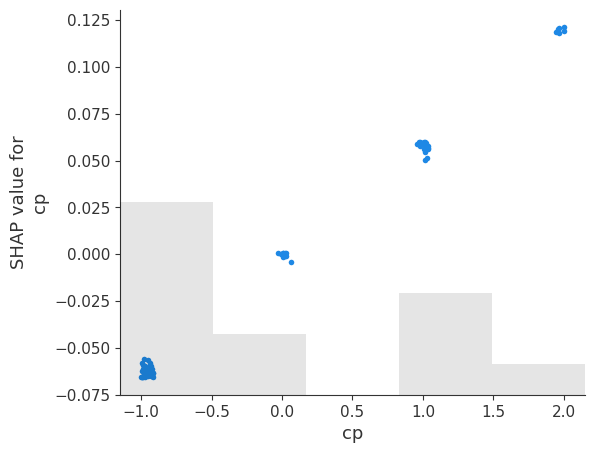

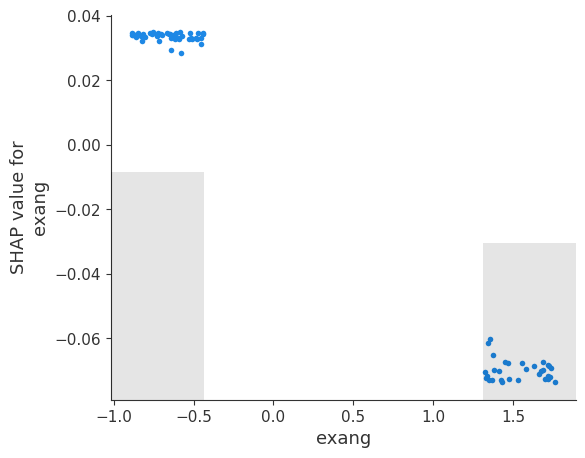

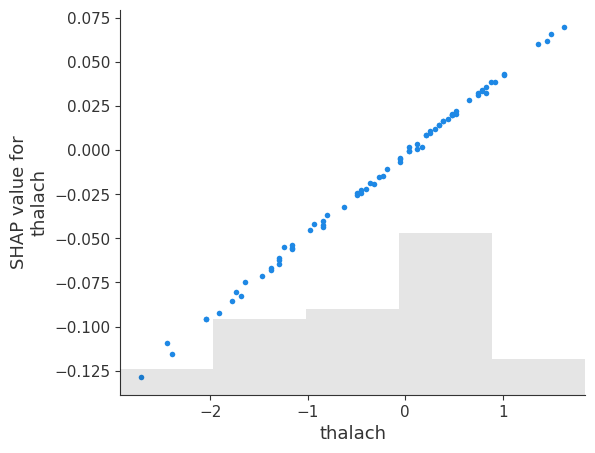

In [184]:
shap.plots.scatter(shap_values_lr_class1[:, "cp"])
shap.plots.scatter(shap_values_lr_class1[:, "exang"])
shap.plots.scatter(shap_values_lr_class1[:, "thalach"])

### Observații

Analiza globală realizată prin summary plot și bar plot arată că cele mai importante 3 caracteristici pentru modelul **Logistic Regression** sunt **cp**, **exang** și **thalach**, urmate de **oldpeak**.

Pentru variabila `cp`, valorile mici sunt asociate cu contribuții negative, în timp ce valorile mai mari cresc scorul predicției și împing modelul spre clasa pozitivă.

În cazul variabile `exang`, valorile ridicate determină contribuții negative importante, reducând probabilitatea clasei pozitive. Valorile mici sunt asociate mai frecvent cu influențe pozitive.

Pentru variabila `thalach`, valorile mari tind să crească scorul predicției, în timp ce valorile mici împing predicția în jos.

Analiza locală realizată prin waterfall plot și force plot pentru observația selectată arată că valorile `exang = 1.524`, `oldpeak = 1.606`, `cp = -0.951` și `ca = 1.154` au contribuit semnificativ la reducerea scorului final al modelului. Predicția finală a fost astfel orientată spre clasa negativă.

Rezultatele confirmă faptul că modelul Logistic Regression utilizează relații liniare clase între caracteristici și probabilitatea apartenenței la clasa pozitivă.

### 11.4 Concluzii comparative ale analizei SHAP

Analiza SHAP evidențiază faptul că toate cele trei modele utilizează un ansamblu comun de caracteristici importante, în special **cp**, **exang**, **oldpeak**, **thalach** și **ca**, ceea ce confirmă relevanța acestora în procesul de clasificare. Deși variabilele importante sunt similare, modul în care fiecare model le utilizează diferă.

**Explainable Boosting Machine** surprinde relații neliniare și efecte diferențiate între valorile aceleiași caracteristici, oferind în același timp un nivel ridicat de interpretabilitate. **Gaussian Naive Bayes** pune accent pe separarea probabilistică a claselor și reacționează puternic la variabile precum `exang` și `oldpeak`. **Logistic Regression** oferă o interpretare mai simplă, bazată pe relații liniare clase între caracteristici și probabilitatea clasei pozitive.

Din perspectiva explicabilității și a performanței predictive, **Explainable Boosting Machine** reprezintă cea mai echilibrată soluție dintre modelele analizate. În schimb, **Logistic Regression** rămâne o variantă robustă și ușor de interpretat, iar **Gaussian Naive Bayes** oferă rezultate competitive printr-o abordare simplă și eficientă.

## Salvarea modelelor și rezultatelor pentru aplicația Streamlit

In [186]:
import joblib
import os

os.makedirs("../models/classification", exist_ok=True)
os.makedirs("../app/assets/classification", exist_ok=True)

joblib.dump(best_ebm, "../models/classification/ebm_model.pkl")
joblib.dump(best_gnb, "../models/classification/gnb_model.pkl")
joblib.dump(best_lr, "../models/classification/logistic_regression_model.pkl")
joblib.dump(best_cat, "../models/classification/catboost_model.pkl")
joblib.dump(best_xgb, "../models/classification/xgboost_model.pkl")

joblib.dump(scaler, "../models/classification/scaler.pkl")

tuned_df.to_csv("../models/classification/classification_metrics.csv", index=False)

Pe lângă bibliotecile utilizate pentru analiza datelor, vizualizare și antrenarea modelelor, în acest notebook am folosit și bibliotecile `joblib` și `os`.

Biblioteca `joblib` am folosit-o pentru salvarea modelelor antrenate și perfecționate. După ce modelele au fost antrenate și evaluate, acestea au fost salvate în fișiere `.pkl`, astfel încât să poată fi reutilizate ulterior în aplicația Streamlit fără a fi nevoie să fie antrenate din nou de fiecare dată. 

Biblioteca `os` a fost folosită pentru gestionarea folderelor și a căilor către fișiere. Mai exact, acestea permite crearea automată a directoarelor necesare pentru salvarea modelelor, în cazul în care acestea nu exostă deja.